In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
%config InlineBackend.figure_format='retina'

import sys
from pathlib import Path
sys.path.append('../')
from utils import *  # key functions for this project


# Lifetime estimation with 200 nm threshold

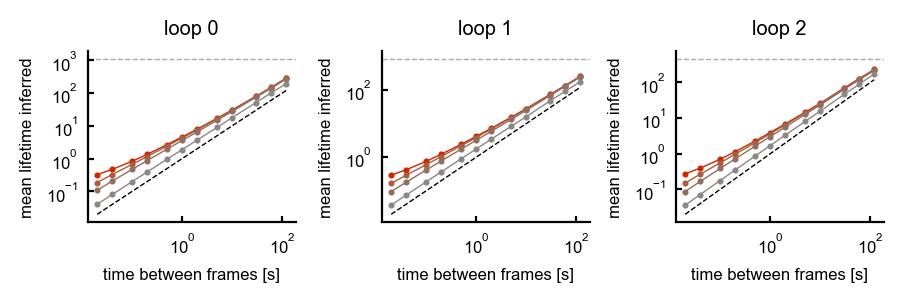

In [16]:
CTCF_loop_lifetimes = pd.read_csv(f'/mnt/md1/jjusuf/looping_review/analysis_data/CTCF_loops_lifetimes.csv')
t_under_50nm_CTCF = pd.read_csv(f'/mnt/md1/jjusuf/looping_review/analysis_data/CTCF_loops_under_threshold_times_200nm.csv')

CTCF_loops = [0, 1, 2]
dt_arr = np.array([0.02, 0.04, 0.1, 0.2, 0.5, 1, 2, 5, 10, 30, 60, 120])

colors = {0: '#cf2600',
          10: '#ab5d3e',
          20: '#916e60',
          50: '#8c8785'}

fig, axs = plt.subplots(1, 3, figsize=(4.5, 1.5))
for ax_index, loop_num in enumerate(CTCF_loops):
    actual_lifetimes = CTCF_loop_lifetimes.loc[CTCF_loop_lifetimes['loop']==loop_num, 'lifetime']
    axs[ax_index].axhline(np.mean(actual_lifetimes), 0, 1, color='#aaaaaa', linestyle='--', linewidth=0.5, zorder=-1)
    for noise in [0, 10, 20, 50]:
        x = []
        y = []
        for dt in dt_arr:
            x.append(dt)
            y.append(np.nanmean(t_under_50nm_CTCF.loc[(t_under_50nm_CTCF['loop']==loop_num) &
                                                (t_under_50nm_CTCF['noise']==noise) &
                                                (t_under_50nm_CTCF['dt']==dt),'time']))
        axs[ax_index].plot(x, y, marker='o', ms=1.2, label=f'{noise}nm', color=colors[noise], linewidth=0.5)
    handles, labels = axs[ax_index].get_legend_handles_labels()
    axs[ax_index].set_xscale('log')
    axs[ax_index].set_yscale('log')
    axs[ax_index].set_xlabel('time between frames [s]')
    axs[ax_index].set_ylabel('mean lifetime inferred');
    #axs[ax_index].legend(handles=handles, title='noise');
    axs[ax_index].set_title(f'loop {loop_num}')
    axs[ax_index].plot(dt_arr, dt_arr, 0, 1, color='black', linestyle='--', linewidth=0.5, zorder=10)
    axs[ax_index].spines[['top','right']].set_visible(False)
    
    axs[ax_index].minorticks_off()

axs[0].set_yticks(10.0**np.array([-1,0,1,2,3]))  # manually adjust first axis ticks

plt.tight_layout()
plt.savefig('../figure_exports/figS1_CTCF_loops_inferred_lifetimes_threshold_200nm.svg')


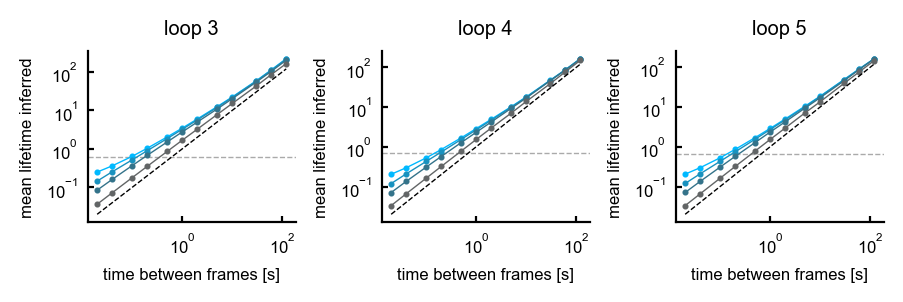

In [17]:
EP_loops_lifetime_histograms = pd.read_pickle('/mnt/md1/jjusuf/looping_review/analysis_data/EP_loops_lifetime_histograms.pkl')
t_under_50nm_EP = pd.read_csv(f'/mnt/md1/jjusuf/looping_review/analysis_data/EP_loops_under_threshold_times_200nm.csv')

EP_loops = [3, 4, 5]
dt_arr = np.array([0.02, 0.04, 0.1, 0.2, 0.5, 1, 2, 5, 10, 30, 60, 120])

colors = {0: '#00b9ff',
          10: '#1992bf',
          20: '#34738a',
          50: '#626566'}

fig, axs = plt.subplots(1, 3, figsize=(4.5, 1.5))
for ax_index, loop_num in enumerate(EP_loops):
    axs[ax_index].axhline(EP_loops_lifetime_histograms.loc[loop_num,'mean'], 0, 1, color='#aaaaaa', linestyle='--', linewidth=0.5, zorder=-1)
    for noise in [0, 10, 20, 50]:
        x = []
        y = []
        for dt in dt_arr:
            x.append(dt)
            y.append(np.nanmean(t_under_50nm_EP.loc[(t_under_50nm_EP['loop']==loop_num) &
                                                    (t_under_50nm_EP['noise']==noise) &
                                                    (t_under_50nm_EP['dt']==dt),'time']))
        axs[ax_index].plot(x, y, marker='o', ms=1.2, label=f'{noise}nm', color=colors[noise], linewidth=0.5)
    handles, labels = axs[ax_index].get_legend_handles_labels()
    axs[ax_index].set_xscale('log')
    axs[ax_index].set_yscale('log')
    axs[ax_index].set_xlabel('time between frames [s]')
    axs[ax_index].set_ylabel('mean lifetime inferred');
    #axs[ax_index].legend(handles=handles, title='noise');
    axs[ax_index].set_title(f'loop {loop_num}')
    axs[ax_index].plot(dt_arr, dt_arr, 0, 1, color='black', linestyle='--', linewidth=0.5, zorder=10)
    axs[ax_index].spines[['top','right']].set_visible(False)

    axs[ax_index].minorticks_off()

plt.tight_layout()
plt.savefig('../figure_exports/figS1_EP_loops_inferred_lifetimes_threshold_200nm.svg')


# Spatiotemporal thresholding

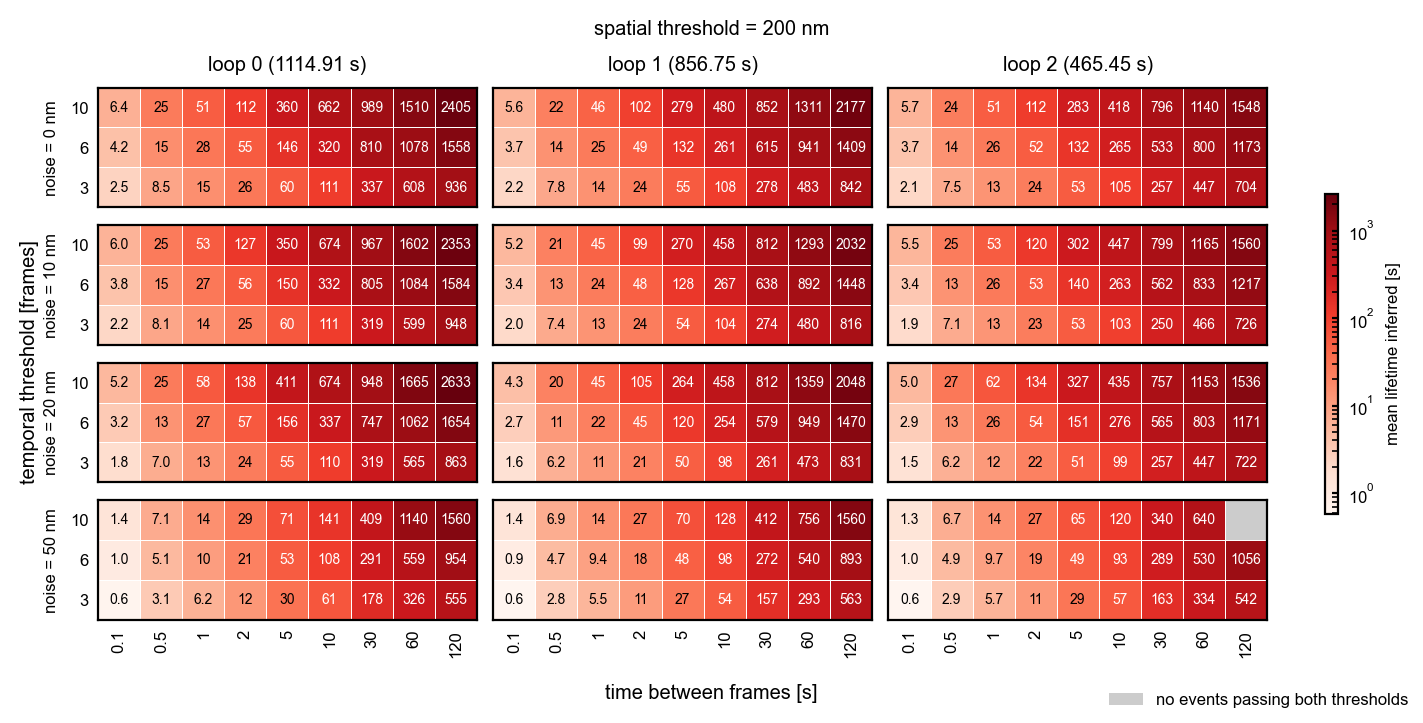

In [ ]:
CTCF_loop_lifetimes = pd.read_csv(f'/mnt/md1/jjusuf/looping_review/analysis_data/CTCF_loops_lifetimes.csv')
CTCF_actual_means = CTCF_loop_lifetimes.groupby('loop')['lifetime'].mean()
under_threshold_times_spatiotemporal = pd.read_csv('/mnt/md1/jjusuf/looping_review/analysis_data/all_loops_under_threshold_times_spatiotemporal.csv')

dt_arr = np.array([0.1, 0.5, 1, 2, 5, 10, 30, 60, 120])
temporal_thr_frames_arr = np.array([3, 6, 10])
noise_arr = [0, 10, 20, 50]

# mean duration of the events passing both thresholds, for each (loop, noise, temporal_threshold_frames, dt)
mean_lifetimes = (under_threshold_times_spatiotemporal
                  .groupby(['loop', 'noise', 'temporal_threshold_frames', 'dt'])['time'].mean().unstack('dt'))
spatial_threshold = under_threshold_times_spatiotemporal['threshold'].unique()[0]

def format_actual_lifetime(seconds):  # minutes for the long CTCF loops, seconds for the short EP ones
    return f'{seconds:.2f} s'
    # return f'{seconds/60:.1f} min' if seconds >= 60 else f'{seconds:.2g} s'

def plot_spatiotemporal_thresholding(mean_lifetimes, loops, cmap, actual_means, dt_arr):
    mean_lifetimes = mean_lifetimes.loc[loops].reindex(columns=dt_arr)
    norm = LogNorm(vmin=np.nanmin(mean_lifetimes.values), vmax=np.nanmax(mean_lifetimes.values))

    fig, axs = plt.subplots(len(noise_arr), len(loops), figsize=(7, 3.5), sharex=True, sharey=True, layout='constrained')
    for row, noise in enumerate(noise_arr):
        for col, loop_num in enumerate(loops):
            ax = axs[row, col]
            grid = (mean_lifetimes.xs((loop_num, noise), level=('loop', 'noise'))
                    .reindex(index=temporal_thr_frames_arr, columns=dt_arr))
            mesh = ax.pcolormesh(grid.to_numpy(), cmap=cmap, norm=norm, edgecolor='white', linewidth=0.3)
            ax.set_aspect(0.95)
            ax.set_facecolor('#cccccc')  # cells with no events passing both thresholds
            for (i, j), value in np.ndenumerate(grid.to_numpy()):
                if np.isfinite(value):
                    ax.text(j + 0.5, i + 0.5, f'{value:.1f}' if value < 10 else f'{value:.0f}',
                            ha='center', va='center', fontsize=5,
                            color='white' if norm(value) > 0.5 else 'black')
            ax.tick_params(length=0)
            if row == 0:
                ax.set_title(f'loop {loop_num} ({format_actual_lifetime(actual_means[loop_num])})')
            if col == 0:
                ax.set_ylabel(f'noise = {noise} nm')

    axs[0, 0].set_xticks(np.arange(len(dt_arr)) + 0.5, [f'{dt:g}' for dt in dt_arr])
    axs[0, 0].set_yticks(np.arange(len(temporal_thr_frames_arr)) + 0.5, [f'{frames:g}' for frames in temporal_thr_frames_arr])
    for ax in axs[-1]:
        ax.tick_params(axis='x', labelrotation=90)

    fig.suptitle(f'spatial threshold = {spatial_threshold} nm')
    fig.supxlabel('time between frames [s]')
    fig.supylabel('temporal threshold [frames]')
    fig.colorbar(mesh, ax=axs, label='mean lifetime inferred [s]', shrink=0.6, aspect=25)
    fig.legend([Rectangle((0, 0), 1, 1, facecolor='#cccccc')], ['no events passing both thresholds'],
               loc='outside lower right', frameon=False)
    return fig, axs

fig, axs = plot_spatiotemporal_thresholding(mean_lifetimes, [0, 1, 2], 'Reds', CTCF_actual_means, dt_arr)
plt.savefig('../figure_exports/figS2_CTCF_spatiotemporal_thresholding.svg')


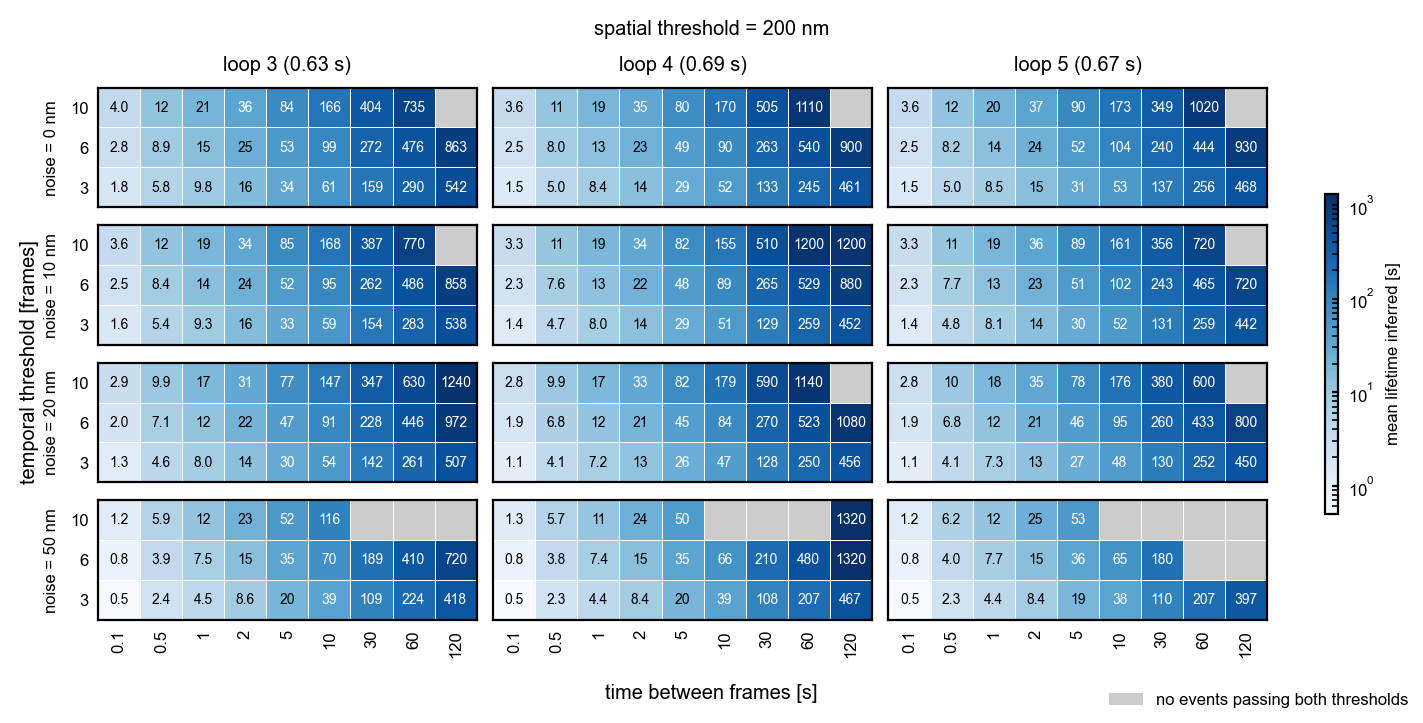

In [ ]:
EP_loops_lifetime_histograms = pd.read_pickle('/mnt/md1/jjusuf/looping_review/analysis_data/EP_loops_lifetime_histograms.pkl')
EP_actual_means = EP_loops_lifetime_histograms['mean'].astype(float)

fig, axs = plot_spatiotemporal_thresholding(mean_lifetimes, [3, 4, 5], 'Blues', EP_actual_means, dt_arr)
plt.savefig('../figure_exports/figS2_EP_spatiotemporal_thresholding.svg')
